In [1]:
!nvidia-smi

Fri May  8 11:06:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q -U vllm pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.4/244.4 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.3/194.3 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3

In [3]:
import torch
import os
import gc
import time
import pandas as pd
import matplotlib.pyplot as plt

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)
print("CUDA version:", torch.version.cuda)
print("Torch version:", torch.__version__)

!nvidia-smi

CUDA available: True
GPU: Tesla T4
CUDA version: 13.0
Torch version: 2.11.0+cu130
Fri May  8 11:11:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |               

In [4]:
from vllm import LLM, SamplingParams

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

llm = LLM(
    model=MODEL_NAME,
    dtype="float16",
    gpu_memory_utilization=0.80,
    max_model_len=1024,
    trust_remote_code=True,
)

INFO 05-08 11:11:49 [utils.py:233] non-default args: {'trust_remote_code': True, 'dtype': 'float16', 'max_model_len': 1024, 'gpu_memory_utilization': 0.8, 'disable_log_stats': True, 'model': 'Qwen/Qwen2.5-0.5B-Instruct'}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

INFO 05-08 11:12:11 [nixl_utils.py:20] Setting UCX_RCACHE_MAX_UNRELEASED to '1024' to avoid a rare memory leak in UCX when using NIXL.
WARNING 05-08 11:12:11 [nixl_utils.py:34] NIXL is not available
WARNING 05-08 11:12:11 [nixl_utils.py:44] NIXL agent config is not available
INFO 05-08 11:12:11 [model.py:555] Resolved architecture: Qwen2ForCausalLM
WARNING 05-08 11:12:11 [model.py:2018] Casting torch.bfloat16 to torch.float16.
INFO 05-08 11:12:11 [model.py:1680] Using max model len 1024
INFO 05-08 11:12:11 [scheduler.py:239] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 05-08 11:12:11 [vllm.py:840] Asynchronous scheduling is enabled.
INFO 05-08 11:12:11 [kernel.py:205] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'])


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

WARNING 05-08 11:12:13 [system_utils.py:157] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized


In [5]:
short_prompt = "Explain KV cache in one sentence."

base_long_prompt = """
You are explaining LLM inference systems to a graduate student.
Please explain the following topics clearly:

1. Prefill phase
2. Decode phase
3. KV cache
4. Attention memory bottleneck
5. Continuous batching
6. PagedAttention
7. Why serving throughput depends on request length
8. Why high concurrency changes GPU utilization

Use concrete examples.
"""

# The T4 value should not be too long, to avoid exceeding max_model_len.
long_prompt = base_long_prompt * 4

print("short prompt chars:", len(short_prompt))
print("long prompt chars:", len(long_prompt))

short prompt chars: 33
long prompt chars: 1408


In [32]:
import subprocess

def get_nvidia_smi_memory_mb():
    result = subprocess.check_output(
        [
            "nvidia-smi",
            "--query-gpu=memory.used",
            "--format=csv,noheader,nounits"
        ]
    )
    return float(result.decode("utf-8").strip().split("\n")[0])

In [33]:
def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        torch.cuda.empty_cache()


def get_gpu_mem_mb():
    if not torch.cuda.is_available():
        return {
            "torch_allocated_mb": 0,
            "torch_reserved_mb": 0,
            "nvidia_smi_used_mb": 0.0,
            }
    return {
            "torch_allocated_mb": torch.cuda.memory_allocated() / 1024 / 1024,
            "torch_reserved_mb": torch.cuda.memory_reserved() / 1024 / 1024,
            "nvidia_smi_used_mb": get_nvidia_smi_memory_mb(), # torch.cuda.memory_reserved() doesn't work, since it use pre-allocation
            }

def run_vllm_case(case_name, prompt_type, output_type, concurrency):
    prompt = short_prompt if prompt_type == "short" else long_prompt
    max_tokens = 32 if output_type == "short" else 128

    prompts = [prompt for _ in range(concurrency)]
    sampling_params = SamplingParams(
        max_tokens=max_tokens,
        temperature=0.0,)

    clear_gpu()
    mem_before = get_gpu_mem_mb()

    start = time.perf_counter()
    outputs = llm.generate(prompts, sampling_params)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    end = time.perf_counter()

    # KPI output
    mem_after = get_gpu_mem_mb()
    elapsed = end - start
    total_output_tokens = sum(len(o.outputs[0].token_ids) for o in outputs)
    output_tokens_per_sec = total_output_tokens / elapsed
    requests_per_sec = concurrency / elapsed
    avg_latency_per_request = elapsed / concurrency

    return {
        "case": case_name,
        "prompt_type": prompt_type,
        "output_type": output_type,
        "concurrency": concurrency,
        "max_output_tokens": max_tokens,
        "elapsed_sec": elapsed,
        "avg_latency_per_request_sec": avg_latency_per_request,
        "total_output_tokens": total_output_tokens,
        "output_tokens_per_sec": output_tokens_per_sec,
        "requests_per_sec": requests_per_sec,
        "torch_allocated_before_mb": mem_before["torch_allocated_mb"],
        "torch_reserved_before_mb": mem_before["torch_reserved_mb"],
        "nvidia_smi_before_mb": mem_before["nvidia_smi_used_mb"],
        "torch_allocated_after_mb": mem_after["torch_allocated_mb"],
        "torch_reserved_after_mb": mem_after["torch_reserved_mb"],
        "nvidia_smi_after_mb": mem_after["nvidia_smi_used_mb"],
    }


In [34]:
cases = [
    ("A1", "short", "short", 1),
    ("A2", "short", "short", 4),
    ("A3", "short", "short", 8),

    ("B1", "short", "long", 1),
    ("B2", "short", "long", 4),
    ("B3", "short", "long", 8),

    ("C1", "long", "short", 1),
    ("C2", "long", "short", 4),
    ("C3", "long", "short", 8),

    ("D1", "long", "long", 1),
    ("D2", "long", "long", 4),
    ("D3", "long", "long", 8),
]

results = []

print("Warmup...")
_ = run_vllm_case("warmup", "short", "short", 1)

for case in cases:
    print("Running:", case)
    try:
        row = run_vllm_case(*case)
        results.append(row)
        print(row)
    except RuntimeError as e:
        print("Failed:", case)
        print(e)
        results.append({
            "case": case[0],
            "prompt_type": case[1],
            "output_type": case[2],
            "concurrency": case[3],
            "max_output_tokens": 32 if case[2] == "short" else 128,
            "elapsed_sec": None,
            "avg_latency_per_request_sec": None,
            "total_output_tokens": None,
            "output_tokens_per_sec": None,
            "requests_per_sec": None,
            "torch_allocated_before_mb": None,
            "torch_reserved_before_mb": None,
            "nvidia_smi_before_mb": None,
            "torch_allocated_after_mb": None,
            "torch_reserved_after_mb": None,
            "nvidia_smi_after_mb": None,
        })

df = pd.DataFrame(results)
df

Warmup...


Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Running: ('A1', 'short', 'short', 1)


Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

...

{'case': 'D2', 'prompt_type': 'long', 'output_type': 'long', 'concurrency': 4, 'max_output_tokens': 128, 'elapsed_sec': 0.8248540790000334, 'avg_latency_per_request_sec': 0.20621351975000834, 'total_output_tokens': 512, 'output_tokens_per_sec': 620.7158490635036, 'requests_per_sec': 4.849342570808622, 'torch_allocated_before_mb': 0.0, 'torch_reserved_before_mb': 0.0, 'nvidia_smi_before_mb': 12199.0, 'torch_allocated_after_mb': 0.0, 'torch_reserved_after_mb': 0.0, 'nvidia_smi_after_mb': 12199.0}
Running: ('D3', 'long', 'long', 8)


Rendering prompts:   0%|          | 0/8 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/8 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

{'case': 'D3', 'prompt_type': 'long', 'output_type': 'long', 'concurrency': 8, 'max_output_tokens': 128, 'elapsed_sec': 0.8732950710000296, 'avg_latency_per_request_sec': 0.1091618838750037, 'total_output_tokens': 1024, 'output_tokens_per_sec': 1172.5704564293428, 'requests_per_sec': 9.16070669085424, 'torch_allocated_before_mb': 0.0, 'torch_reserved_before_mb': 0.0, 'nvidia_smi_before_mb': 12199.0, 'torch_allocated_after_mb': 0.0, 'torch_reserved_after_mb': 0.0, 'nvidia_smi_after_mb': 12199.0}


,case,prompt_type,output_type,concurrency,max_output_tokens,elapsed_sec,avg_latency_per_request_sec,total_output_tokens,output_tokens_per_sec,requests_per_sec,torch_allocated_before_mb,torch_reserved_before_mb,nvidia_smi_before_mb,torch_allocated_after_mb,torch_reserved_after_mb,nvidia_smi_after_mb
0,A1,short,short,1,32,0.233779,0.233779,32,136.881280,4.277540,0.0,0.0,12199.0,0.0,0.0,12199.0
1,A2,short,short,4,32,0.277662,0.069415,128,460.992759,14.406024,0.0,0.0,12199.0,0.0,0.0,12199.0
2,A3,short,short,8,32,0.276674,0.034584,256,925.275445,28.914858,0.0,0.0,12199.0,0.0,0.0,12199.0
3,B1,short,long,1,128,0.838923,0.838923,128,152.576659,1.192005,0.0,0.0,12199.0,0.0,0.0,12199.0
4,B2,short,long,4,128,0.792735,0.198184,512,645.865167,5.045822,0.0,0.0,12199.0,0.0,0.0,12199.0
5,B3,short,long,8,128,0.843571,0.105446,1024,1213.887218,9.483494,0.0,0.0,12199.0,0.0,0.0,12199.0
6,C1,long,short,1,32,0.248928,0.248928,32,128.551146,4.017223,0.0,0.0,12199.0,0.0,0.0,12199.0
7,C2,long,short,4,32,0.266531,0.066633,128,480.244281,15.007634,0.0,0.0,12199.0,0.0,0.0,12199.0
8,C3,long,short,8,32,0.281376,0.035172,256,909.815375,28.431730,0.0,0.0,12199.0,0.0,0.0,12199.0
9,D1,long,long,1,128,0.822878,0.822878,128,155.551549,1.215246,0.0,0.0,12199.0,0.0,0.0,12199.0


In [35]:
df_display = df.copy()

round_cols = [
    "elapsed_sec",
    "avg_latency_per_request_sec",
    "output_tokens_per_sec",
    "requests_per_sec",
    "torch_allocated_before_mb",
    "torch_reserved_before_mb",
    "nvidia_smi_before_mb",
    "torch_allocated_after_mb",
    "torch_reserved_after_mb",
    "nvidia_smi_after_mb",
]

for col in round_cols:
    df_display[col] = df_display[col].astype("float").round(3)

df_display

,case,prompt_type,output_type,concurrency,max_output_tokens,elapsed_sec,avg_latency_per_request_sec,total_output_tokens,output_tokens_per_sec,requests_per_sec,torch_allocated_before_mb,torch_reserved_before_mb,nvidia_smi_before_mb,torch_allocated_after_mb,torch_reserved_after_mb,nvidia_smi_after_mb
0,A1,short,short,1,32,0.234,0.234,32,136.881,4.278,0.0,0.0,12199.0,0.0,0.0,12199.0
1,A2,short,short,4,32,0.278,0.069,128,460.993,14.406,0.0,0.0,12199.0,0.0,0.0,12199.0
2,A3,short,short,8,32,0.277,0.035,256,925.275,28.915,0.0,0.0,12199.0,0.0,0.0,12199.0
3,B1,short,long,1,128,0.839,0.839,128,152.577,1.192,0.0,0.0,12199.0,0.0,0.0,12199.0
4,B2,short,long,4,128,0.793,0.198,512,645.865,5.046,0.0,0.0,12199.0,0.0,0.0,12199.0
5,B3,short,long,8,128,0.844,0.105,1024,1213.887,9.483,0.0,0.0,12199.0,0.0,0.0,12199.0
6,C1,long,short,1,32,0.249,0.249,32,128.551,4.017,0.0,0.0,12199.0,0.0,0.0,12199.0
7,C2,long,short,4,32,0.267,0.067,128,480.244,15.008,0.0,0.0,12199.0,0.0,0.0,12199.0
8,C3,long,short,8,32,0.281,0.035,256,909.815,28.432,0.0,0.0,12199.0,0.0,0.0,12199.0
9,D1,long,long,1,128,0.823,0.823,128,155.552,1.215,0.0,0.0,12199.0,0.0,0.0,12199.0


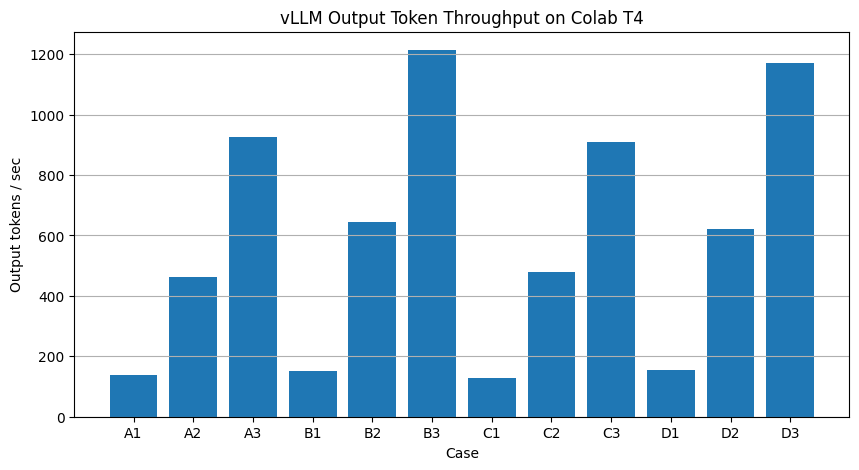

Saved to day12_vllm_t4_results.csv


In [36]:
plot_df = df.dropna(subset=["output_tokens_per_sec"])

plt.figure(figsize=(10, 5))
plt.bar(plot_df["case"], plot_df["output_tokens_per_sec"])
plt.xlabel("Case")
plt.ylabel("Output tokens / sec")
plt.title("vLLM Output Token Throughput on Colab T4")
plt.grid(axis="y")
plt.show()

df_display.to_csv("day12_vllm_t4_results.csv", index=False)
print("Saved to day12_vllm_t4_results.csv")

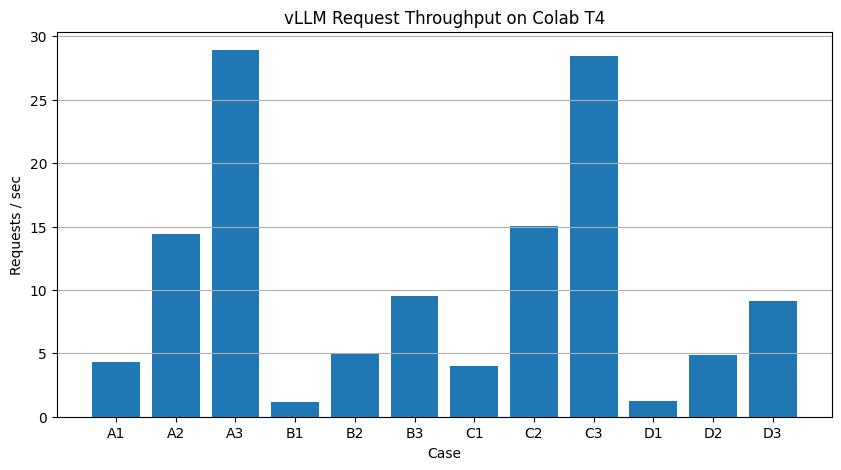

In [37]:
plot_df = df.dropna(subset=["requests_per_sec"])

plt.figure(figsize=(10, 5))
plt.bar(plot_df["case"], plot_df["requests_per_sec"])
plt.xlabel("Case")
plt.ylabel("Requests / sec")
plt.title("vLLM Request Throughput on Colab T4")
plt.grid(axis="y")
plt.show()

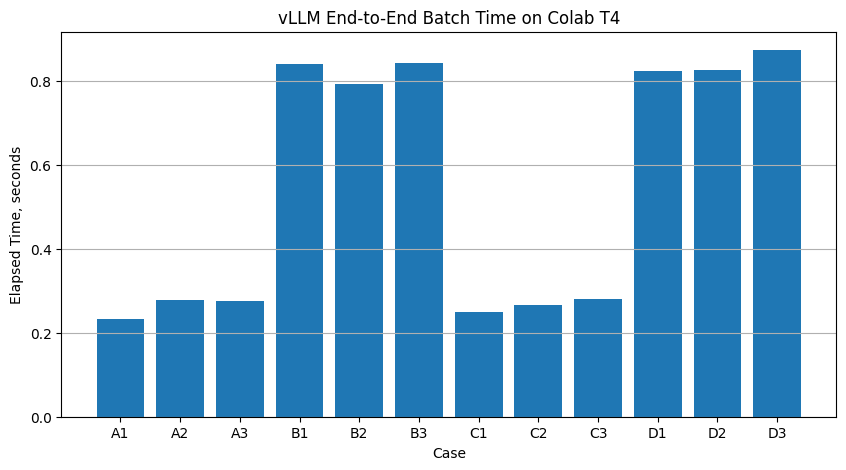

In [38]:
plot_df = df.dropna(subset=["elapsed_sec"])

plt.figure(figsize=(10, 5))
plt.bar(plot_df["case"], plot_df["elapsed_sec"])
plt.xlabel("Case")
plt.ylabel("Elapsed Time, seconds")
plt.title("vLLM End-to-End Batch Time on Colab T4")
plt.grid(axis="y")
plt.show()

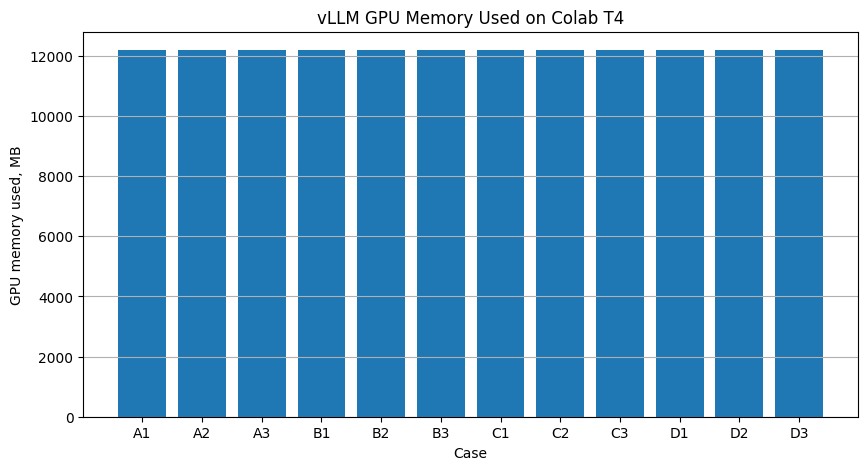

In [39]:
plot_df = df.dropna(subset=["nvidia_smi_after_mb"])

plt.figure(figsize=(10, 5))
plt.bar(plot_df["case"], plot_df["nvidia_smi_after_mb"])
plt.xlabel("Case")
plt.ylabel("GPU memory used, MB")
plt.title("vLLM GPU Memory Used on Colab T4")
plt.grid(axis="y")
plt.show()